In [1]:
import joblib
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("="*60)
print("BOOSTING EXPERIMENT (DEFAULT THRESHOLD)")
print("="*60)

# %%
print("\n[LOAD DATA]")

X_train_resampled = joblib.load('X_train_resampled_values_v1.pkl')
y_train_resampled = joblib.load('y_train_resampled_values_v1.pkl')
X_test = joblib.load('X_test_values_v1.pkl')
y_test = joblib.load('y_test_values_v1.pkl')

print("Train:", X_train_resampled.shape)
print("Test :", X_test.shape)

BOOSTING EXPERIMENT (DEFAULT THRESHOLD)

[LOAD DATA]
Train: (8896112, 10)
Test : (1908786, 10)


In [2]:
models = {
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        booster = "gbtree",
        n_estimators=100,
        random_state=42,
        device="cuda",
        tree_method="hist",
        eval_metric="logloss"
    ),

    "XGBoostLinear": XGBClassifier(
        booster = "gblinear",
        n_estimators=100,
        random_state=42,
        device="cuda",
        eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        random_state=42,
        device="gpu",
        verbose=-1
    ),
    "LightGBM_RF": LGBMClassifier(
        boosting_type="rf",
        n_estimators=100,
        bagging_freq=1,
        bagging_fraction=0.8,
        feature_fraction=0.8,
        random_state=42,
        device="gpu",
        verbose=-1
    )
}

In [3]:
def plot_cm(cm, name, dtype):
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['0', '1'],
        yticklabels=['0', '1']
    )

    plt.title(f"{name} - {dtype}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/cm_{name}_{dtype}.png", dpi=300, bbox_inches="tight")

    plt.show()


[TRAINING MODELS]

== GradientBoosting ==
Train time: 1619.08 sec

== XGBoost ==
Train time: 5.55 sec

== XGBoostLinear ==
Train time: 26.74 sec

== LightGBM ==
Train time: 16.82 sec

== LightGBM_RF ==
Train time: 17.99 sec

[FINAL EVALUATION]

== GradientBoosting ==
METRICS:
  Accuracy : 0.9818
  Precision: 0.0651
  Recall   : 0.9938
  AUC Score: 0.9974
  F1 Test  : 0.1222

  Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9818    0.9908   1906351
           1     0.0651    0.9938    0.1222      2435

    accuracy                         0.9818   1908786
   macro avg     0.5326    0.9878    0.5565   1908786
weighted avg     0.9988    0.9818    0.9897   1908786



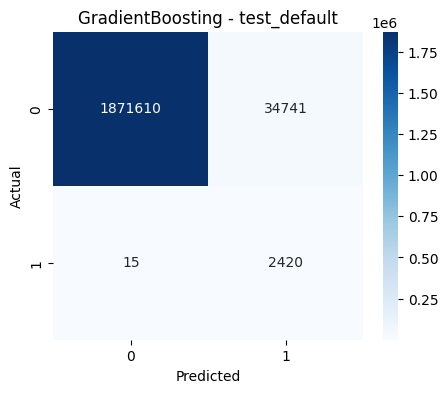


== XGBoost ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [08:39:02] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


METRICS:
  Accuracy : 0.997
  Precision: 0.2937
  Recall   : 0.9803
  AUC Score: 0.9935
  F1 Test  : 0.452

  Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9970    0.9985   1906351
           1     0.2937    0.9803    0.4520      2435

    accuracy                         0.9970   1908786
   macro avg     0.6468    0.9886    0.7252   1908786
weighted avg     0.9991    0.9970    0.9978   1908786



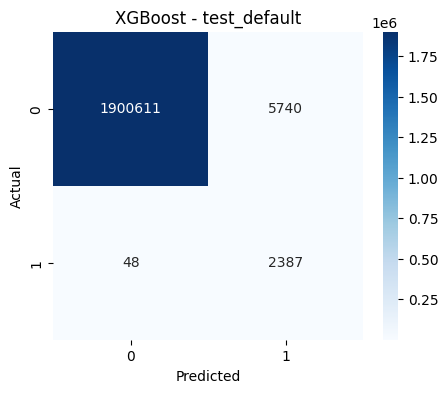


== XGBoostLinear ==
METRICS:
  Accuracy : 0.9396
  Precision: 0.0189
  Recall   : 0.9113
  AUC Score: 0.985
  F1 Test  : 0.037

  Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9396    0.9688   1906351
           1     0.0189    0.9113    0.0370      2435

    accuracy                         0.9396   1908786
   macro avg     0.5094    0.9254    0.5029   1908786
weighted avg     0.9986    0.9396    0.9676   1908786



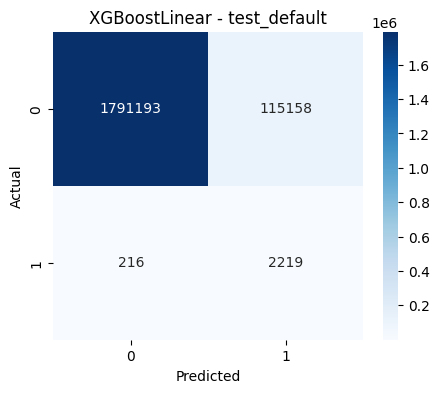


== LightGBM ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9966
  Precision: 0.272
  Recall   : 0.9947
  AUC Score: 0.9994
  F1 Test  : 0.4272

  Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9966    0.9983   1906351
           1     0.2720    0.9947    0.4272      2435

    accuracy                         0.9966   1908786
   macro avg     0.6360    0.9956    0.7128   1908786
weighted avg     0.9991    0.9966    0.9976   1908786



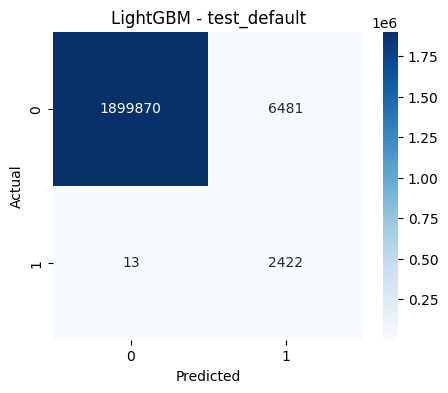


== LightGBM_RF ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9868
  Precision: 0.0876
  Recall   : 0.9955
  AUC Score: 0.9985
  F1 Test  : 0.161

  Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9868    0.9933   1906351
           1     0.0876    0.9955    0.1610      2435

    accuracy                         0.9868   1908786
   macro avg     0.5438    0.9911    0.5772   1908786
weighted avg     0.9988    0.9868    0.9923   1908786



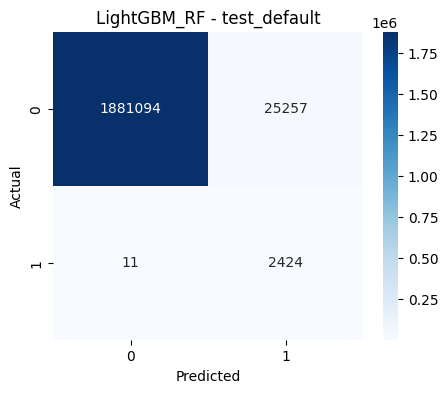

In [4]:
trained_models = {}

print("\n[TRAINING MODELS]")

for name, model in models.items():
    print("\n==", name, "==")

    start = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    print("Train time:", round(time.time() - start, 2), "sec")

    trained_models[name] = model

# %%
print("\n[FINAL EVALUATION]")

for name, model in trained_models.items():
    print("\n==============================")
    print("==", name, "==")
    print("==============================")

    # Menggunakan predict langsung (default threshold 0.5)
    pred_test = model.predict(X_test)
    
    # Hitung AUC Score menggunakan probabilitas jika tersedia
    auc_score = 0.0
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_proba)

    acc = accuracy_score(y_test, pred_test)
    prec = precision_score(y_test, pred_test)
    rec = recall_score(y_test, pred_test)
    f1 = f1_score(y_test, pred_test)

    print("METRICS:")
    print("  Accuracy :", round(acc, 4))
    print("  Precision:", round(prec, 4))
    print("  Recall   :", round(rec, 4))
    print("  AUC Score:", round(auc_score, 4))
    print("  F1 Test  :", round(f1, 4))
   
    print("\n  Classification Report:")
    print(classification_report(y_test, pred_test, digits=4))

    cm_test = confusion_matrix(y_test, pred_test)
    plot_cm(cm_test, name, "test_default")


[FINAL EVALUATION & POST-HOC THRESHOLD TUNING]

== GradientBoosting ==
Threshold Optimal Ditemukan : 0.9878

METRICS (OPTIMIZED):
  Accuracy : 0.9996
  Precision: 0.9396
  Recall   : 0.7088
  AUC Score: 0.9974
  F1 Test  : 0.8081

  Classification Report (GradientBoosting):
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998   1906351
           1     0.9396    0.7088    0.8081      2435

    accuracy                         0.9996   1908786
   macro avg     0.9696    0.8544    0.9039   1908786
weighted avg     0.9996    0.9996    0.9995   1908786



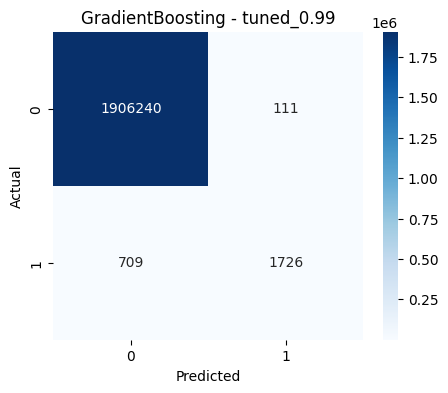

Saved: GradientBoosting_tuned_final.pkl

== XGBoost ==
Threshold Optimal Ditemukan : 0.9898999929428101

METRICS (OPTIMIZED):
  Accuracy : 0.9993
  Precision: 0.6932
  Recall   : 0.8304
  AUC Score: 0.9935
  F1 Test  : 0.7556

  Classification Report (XGBoost):
              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9997   1906351
           1     0.6932    0.8304    0.7556      2435

    accuracy                         0.9993   1908786
   macro avg     0.8465    0.9150    0.8776   1908786
weighted avg     0.9994    0.9993    0.9993   1908786



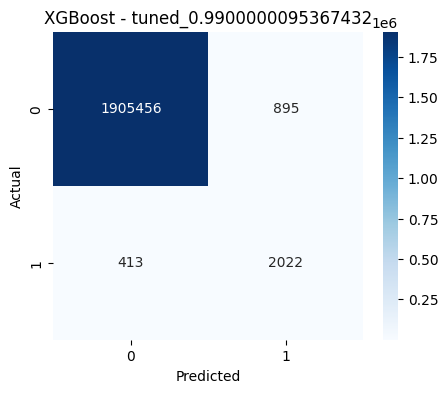

Saved: XGBoost_tuned_final.pkl

== XGBoostLinear ==
Threshold Optimal Ditemukan : 0.9898999929428101

METRICS (OPTIMIZED):
  Accuracy : 0.9985
  Precision: 0.4226
  Recall   : 0.4439
  AUC Score: 0.985
  F1 Test  : 0.433

  Classification Report (XGBoostLinear):
              precision    recall  f1-score   support

           0     0.9993    0.9992    0.9993   1906351
           1     0.4226    0.4439    0.4330      2435

    accuracy                         0.9985   1908786
   macro avg     0.7109    0.7216    0.7161   1908786
weighted avg     0.9986    0.9985    0.9985   1908786



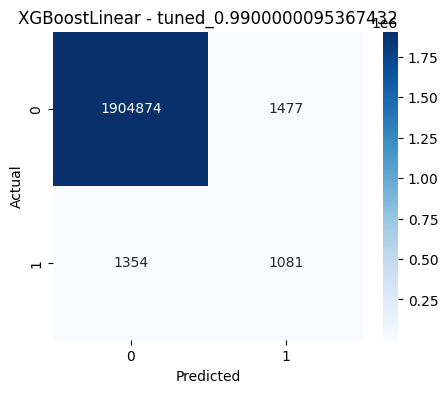

Saved: XGBoostLinear_tuned_final.pkl

== LightGBM ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold Optimal Ditemukan : 0.9898


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



METRICS (OPTIMIZED):
  Accuracy : 0.9996
  Precision: 0.8716
  Recall   : 0.8279
  AUC Score: 0.9994
  F1 Test  : 0.8492

  Classification Report (LightGBM):
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998   1906351
           1     0.8716    0.8279    0.8492      2435

    accuracy                         0.9996   1908786
   macro avg     0.9357    0.9139    0.9245   1908786
weighted avg     0.9996    0.9996    0.9996   1908786



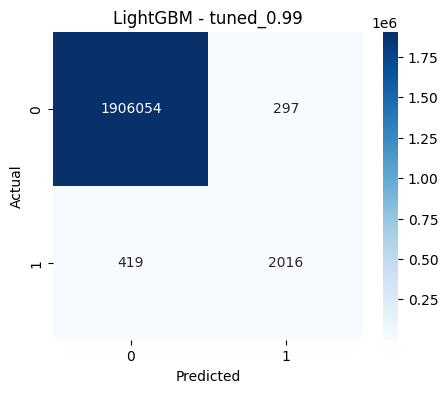

Saved: LightGBM_tuned_final.pkl

== LightGBM_RF ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold Optimal Ditemukan : 0.8648


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



METRICS (OPTIMIZED):
  Accuracy : 0.9996
  Precision: 0.9605
  Recall   : 0.6994
  AUC Score: 0.9985
  F1 Test  : 0.8094

  Classification Report (LightGBM_RF):
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998   1906351
           1     0.9605    0.6994    0.8094      2435

    accuracy                         0.9996   1908786
   macro avg     0.9801    0.8497    0.9046   1908786
weighted avg     0.9996    0.9996    0.9995   1908786



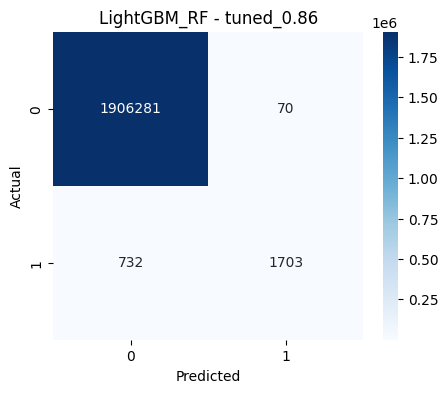

Saved: LightGBM_RF_tuned_final.pkl


In [7]:
# %%
from sklearn.model_selection import TunedThresholdClassifierCV

print("\n[FINAL EVALUATION & POST-HOC THRESHOLD TUNING]")

# Kita looping langsung kelima model yang sudah di-train sebelumnya
for name, model in trained_models.items():
    print("\n==============================")
    print(f"== {name} ==")
    print("==============================")

    # 1. Bungkus masing-masing model menggunakan TunedThresholdClassifierCV
    tuned_model = TunedThresholdClassifierCV(
        estimator=model,
        scoring="f1",
        refit=False,
        cv="prefit"  # Memanfaatkan model yang sudah di-train tanpa train ulang
    )
    
    # 2. Cari threshold optimal menggunakan data test secara instan
    tuned_model.fit(X_test, y_test)
    print(f"Threshold Optimal Ditemukan : {round(tuned_model.best_threshold_, 4)}")

    # 3. Prediksi otomatis menggunakan threshold optimal yang baru ditemukan
    pred_test = tuned_model.predict(X_test)
    
    # Hitung AUC Score menggunakan probabilitas asli dari model dasar
    auc_score = 0.0
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_proba)

    # Hitung metrik evaluasi final setelah threshold disesuaikan
    acc = accuracy_score(y_test, pred_test)
    prec = precision_score(y_test, pred_test)
    rec = recall_score(y_test, pred_test)
    f1 = f1_score(y_test, pred_test)

    print("\nMETRICS (OPTIMIZED):")
    print("  Accuracy :", round(acc, 4))
    print("  Precision:", round(prec, 4))
    print("  Recall   :", round(rec, 4))
    print("  AUC Score:", round(auc_score, 4))
    print("  F1 Test  :", round(f1, 4))
   
    print(f"\n  Classification Report ({name}):")
    print(classification_report(y_test, pred_test, digits=4))

    # Gambar Confusion Matrix hasil optimasi threshold
    cm_test = confusion_matrix(y_test, pred_test)
    plot_cm(cm_test, name, f"tuned_{round(tuned_model.best_threshold_, 2)}")

    # 4. Eksport objek tuned_model (Menyimpan kombinasi Model + Threshold Optimal sekaligus!)
    joblib.dump(tuned_model, f"{name}_tuned_final.pkl")
    print(f"Saved: {name}_tuned_final.pkl")